# LSTM

<https://d2l.ai/chapter_recurrent-modern/lstm.html>

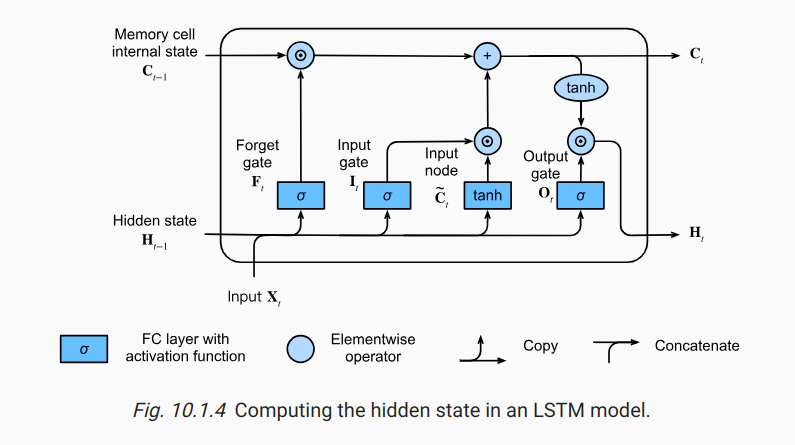


# concise


## tokens

In [36]:
# download data
import os
import subprocess

DATA_FILE = os.path.join('datasets', 'book.txt')
DATA_URL = 'https://www.gutenberg.org/cache/epub/35/pg35.txt'
subprocess.run(['mkdir', '-p', 'datasets'])
subprocess.run(['wget', '-O', DATA_FILE, DATA_URL])

--2024-10-18 16:43:30--  https://www.gutenberg.org/cache/epub/35/pg35.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 204427 (200K) [text/plain]
Saving to: ‘datasets/book.txt’

     0K .......... .......... .......... .......... .......... 25% 90.4K 2s
    50K .......... .......... .......... .......... .......... 50%  184K 1s
   100K .......... .......... .......... .......... .......... 75%  502M 0s
   150K .......... .......... .......... .......... ......... 100%  203K=1.1s

2024-10-18 16:43:32 (187 KB/s) - ‘datasets/book.txt’ saved [204427/204427]



CompletedProcess(args=['wget', '-O', 'datasets/book.txt', 'https://www.gutenberg.org/cache/epub/35/pg35.txt'], returncode=0)

In [37]:
# load data
with open(DATA_FILE, 'r') as f:
    data_raw = f.read()

data_raw[:20]

'\ufeffThe Project Gutenbe'

In [38]:
# tokenize data
tokens = list(data_raw)
tokens[100:110]

['n', ' ', 't', 'h', 'e', ' ', 'U', 'n', 'i', 't']

In [39]:
# vocabulary
from collections import Counter
class Vocab:
    def __init__(self, tokens, min_freq=0, reserved_tokens=[]):
        counter = Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        self.unk, uniq_tokens = 0, ['<unk>'] + reserved_tokens
        uniq_tokens += [token for token, freq in self.token_freqs if freq >= min_freq and token not in uniq_tokens]
        self.idx_to_token, self.token_to_idx = [], dict()
        for token in uniq_tokens:
            self.idx_to_token.append(token)
            self.token_to_idx[token] = len(self.idx_to_token) - 1
    def to_idx(self, tokens):
        return [self.token_to_idx.get(token, self.unk) for token in tokens]
    def to_token(self, indices):
        return [self.idx_to_token[idx] for idx in indices]
    def __len__(self):
        return len(self.idx_to_token)
    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

In [40]:
vocab = Vocab(tokens, min_freq=10)
indices = vocab.to_idx(tokens)
words = vocab.to_token(indices)
corpus = indices
indices[:10], words[:10], (len(indices), len(words))


([0, 28, 10, 2, 1, 35, 9, 5, 38, 2],
 ['<unk>', 'T', 'h', 'e', ' ', 'P', 'r', 'o', 'j', 'e'],
 (198910, 198910))

In [41]:
import numpy as np

def create_data_batch(data, batch_size, num_steps):
    """
    data_output: (num_batches, batch_size, num_steps)
    """
    num_batches = len(data) // (batch_size * num_steps)
    data_output = data[:num_batches * batch_size * num_steps]
    data_output = np.array(data_output).reshape((batch_size, num_batches * num_steps))
    data_output = data_output.reshape((num_batches, batch_size, num_steps))
    return data_output

In [42]:
data = create_data_batch(corpus, 20, 32)
data.shape

(310, 20, 32)

## models

In [49]:
import torch
from torch import nn

class LSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers, batch_size):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.batch_size = batch_size
        embed_size = hidden_size # for simplicity
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    def forward(self, x, hidden):
        # input: 
        # x: (batch_size, num_steps)
        x = self.embedding(x)
        x, hidden = self.rnn(x, hidden) 
        x = self.linear(x)
        # output:
        # x: (batch_size, num_steps, vocab_size) , the last layer output
        # hidden: (num_layers, batch_size, hidden_size), the last time step hidden state
        return x, hidden
    
    def pred_init_hidden(self):
        return (torch.zeros(self.num_layers, 1, self.hidden_size).to(self.device),
                torch.zeros(self.num_layers, 1, self.hidden_size).to(self.device))
    
    def predict(self, input_str, num_steps, vocab):
        self.eval()
        input_indices = torch.tensor([vocab.to_idx(list(input_str))], dtype=torch.long).to(self.device)
        hidden = self.pred_init_hidden()
        output_str = input_str
        for _ in range(num_steps):
            output, hidden = self.forward(input_indices, hidden)
            next_token_idx = torch.argmax(output[:, -1, :], dim=1).item()
            next_token = vocab.idx_to_token[next_token_idx]
            output_str += next_token
            input_indices = torch.cat((input_indices, torch.tensor([[next_token_idx]], dtype=torch.long).to(self.device)), dim=1)
        return output_str

        

## train

In [44]:
class Trainer:
    def __init__(self, model, vocab, lr):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.vocab = vocab
        self.model = model.to(self.device)
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.hidden = None
        
    def init_hidden(self):
        return (torch.zeros(self.model.num_layers, self.model.batch_size, self.model.hidden_size).to(self.device),
                torch.zeros(self.model.num_layers, self.model.batch_size, self.model.hidden_size).to(self.device))
    
    def train(self, data, num_epochs):
        for epoch in range(num_epochs):
            hidden = self.init_hidden()
            total_loss = 0
            correct = 0
            total = 0
            for batch in data:
                x, y = batch[:, :-1].to(self.device), batch[:, 1:].to(self.device)
                # why apply output hidden state as next batch initial hidden state?
                # look back to how we seperate corpus.
                y_hat, hidden = self.model(x, hidden)
                y_hat, y = y_hat.reshape(-1, len(self.vocab)), y.reshape(-1)
                loss = self.criterion(y_hat, y)
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                hidden = (hidden[0].detach(), hidden[1].detach())
                total_loss += loss.item()
                predicted = torch.argmax(y_hat, dim=1)
                correct += (predicted == y).sum().item()
                total += len(y)
                
            print(f"loss value of epoch {epoch+1}", total_loss/len(data))
            print(f"accuracy of epoch {epoch+1}", correct/total)

**Detach**: `y2_detached = y2.detach()` creates a new tensor `y2_detached` that shares the same data as `y2` but does not track operations for gradient computation.

In [45]:
data.shape

(310, 20, 32)

In [50]:
lstm = LSTM(vocab_size=len(vocab), hidden_size=256, num_layers=4, batch_size=20)
trainer = Trainer(lstm, vocab, lr=0.01)
data = torch.tensor(data, dtype=torch.long)
trainer.train(data, num_epochs=1)


/tmp/ipykernel_4023/164707817.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data, dtype=torch.long)


loss value of epoch 1 2.3487651421177773
accuracy of epoch 1 0.3438241415192508


In [51]:
lstm.predict("hello ", 20, vocab)

'hello the Project of the P'

In [50]:
import torch
from torch import nn

y1 = torch.randn(2, 3, 4)
y1.detach()

torch.Size([2, 3, 4])

In [32]:
z1 = torch.randint(0, 40, (2, 4, 5))
z1.reshape(-1, 5), z1.view(-1, 5), z1

(tensor([[15, 38,  6,  9,  0],
         [37, 27,  4, 15, 25],
         [21, 30,  5,  3,  0],
         [ 2,  9, 17, 29, 13],
         [28, 37, 19,  6, 31],
         [19, 32,  1, 17, 21],
         [17,  9, 36, 13, 20],
         [33, 35, 13, 38, 34]]),
 tensor([[15, 38,  6,  9,  0],
         [37, 27,  4, 15, 25],
         [21, 30,  5,  3,  0],
         [ 2,  9, 17, 29, 13],
         [28, 37, 19,  6, 31],
         [19, 32,  1, 17, 21],
         [17,  9, 36, 13, 20],
         [33, 35, 13, 38, 34]]),
 tensor([[[15, 38,  6,  9,  0],
          [37, 27,  4, 15, 25],
          [21, 30,  5,  3,  0],
          [ 2,  9, 17, 29, 13]],
 
         [[28, 37, 19,  6, 31],
          [19, 32,  1, 17, 21],
          [17,  9, 36, 13, 20],
          [33, 35, 13, 38, 34]]]))